KERNEL PCA

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_circles
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler

In [5]:
X,y=make_circles(n_samples=400,factor=0.3,noise=0.05,random_state=42) #factor rappresenta il fattore di scala tra il cerchio interno e quello più esterno
print(X.shape)
#print(X)
print(y.shape)
#print(y)

(400, 2)
(400,)


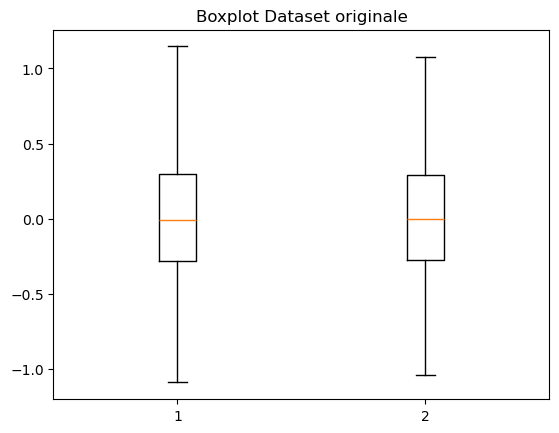

In [8]:
plt.boxplot(X)
plt.title("Boxplot Dataset originale")
plt.show()

La media di entrambe le feature è 0 ed i valori oscillano tra -1 e 1
I dati sono già abbastanza standarizzati, ma conviene comuque fare una standarizzazione prima di
passare a qualsiasi algoritmo di ML

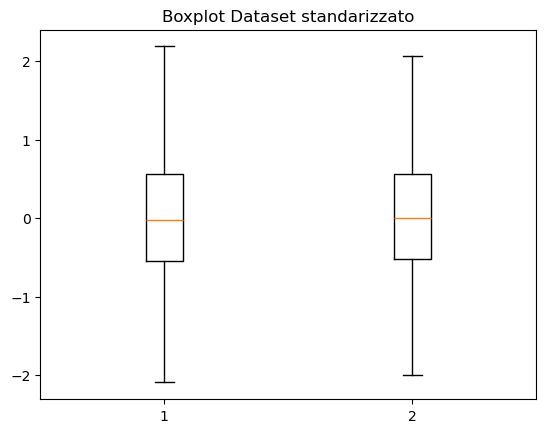

In [9]:
scaler=StandardScaler(  )
X_std=scaler.fit_transform(X)

plt.boxplot(X_std)
plt.title("Boxplot Dataset standarizzato")
plt.show()

In [14]:
kpca=KernelPCA(n_components=2,kernel="rbf")  #rbf è kernel gaussiano
X_kpca=kpca.fit_transform(X_std)

print(X_kpca.shape)

(400, 2)


Applichiamo un modello di ML sia ai dati standarizzati sia quelli con k-pca applicata. Per vedere i risultati che si ottengono (utiliziamo k-means)

In [22]:
n_cluster=2
random_state=42

#
#alleniamo i due modelli
#

kmeans_std=KMeans(n_clusters=n_cluster,random_state=random_state, n_init="auto")
cluster_std=kmeans_std.fit_predict(X_std)
centroidi_std=kmeans_std.cluster_centers_

kmeans_kpca=KMeans(n_clusters=n_cluster,random_state=random_state, n_init="auto")
cluster_kpca=kmeans_kpca.fit_predict(X_kpca)
centroidi_kpca=kmeans_kpca.cluster_centers_



c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


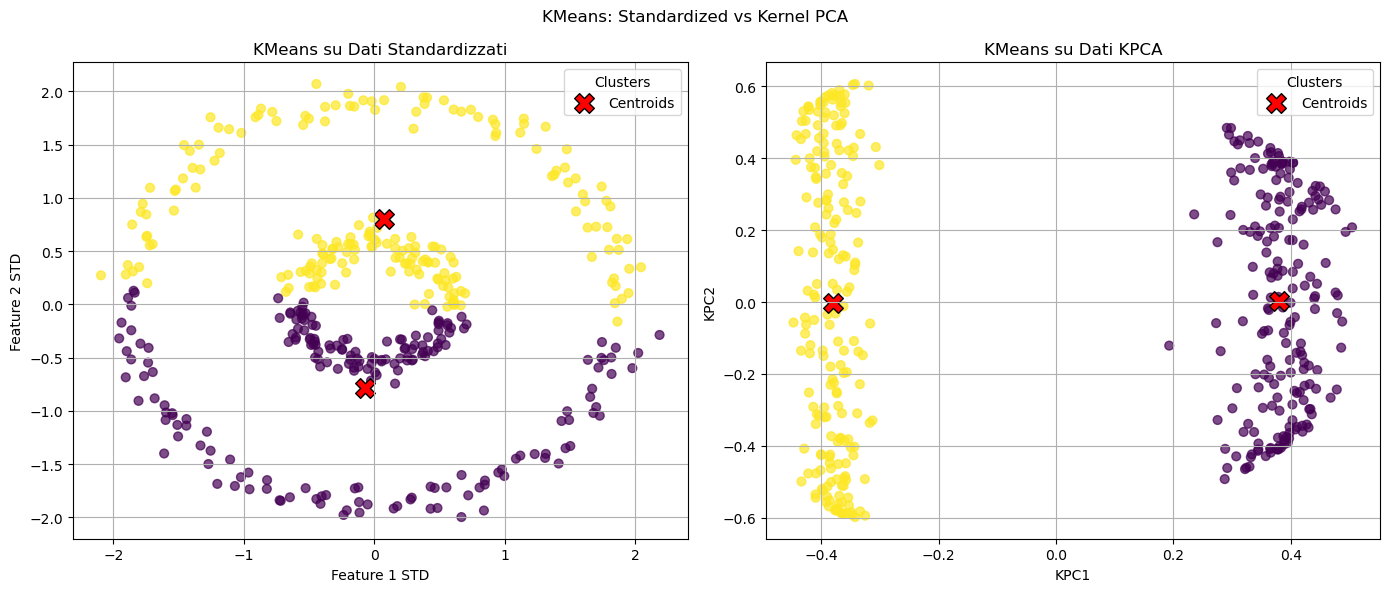

In [ ]:
from matplotlib.pyplot import scatter

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("KMeans: Standardized vs Kernel PCA")
             
axes[0].scatter(X_std[:, 0], X_std[:, 1], c=cluster_std, cmap='viridis', s=40, alpha=0.7)
axes[0].scatter(centroidi_std[:, 0], centroidi_std[:, 1], marker='X', s=200, c='red', edgecolor='black', label='Centroids')
axes[0].set_title('KMeans su Dati Standardizzati')
axes[0].set_xlabel('Feature 1 STD')
axes[0].set_ylabel('Feature 2 STD')
axes[0].grid()
axes[0].legend(title='Clusters')

axes[1].scatter(X_kpca[:, 0], X_kpca[:, 1], c=cluster_kpca, cmap='viridis', s=40, alpha=0.7)
axes[1].scatter(centroidi_kpca[:, 0], centroidi_kpca[:, 1], marker='X', s=200, c='red', edgecolor='black', label='Centroids')
axes[1].set_title('KMeans su Dati KPCA')
axes[1].set_xlabel('KPC1')
axes[1].set_ylabel('KPC2')
axes[1].grid()
axes[1].legend(title='Clusters')

plt.tight_layout()
plt.show()